In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
from matplotlib import cm
#from matplotlib import norm
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')
import os

plotsdir  = '/Users/billiemeadowcroft//Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Dome/Plots/'


import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [44]:
#Data:

# Original Data
Avtaus =[14234.0, 17030.666666666668, 21329.333333333332, 38244.666666666664, 48664.666666666664, 150533.33333333334] 
Stdtaus= [2172.0, 2103.1102892832055, 1442.1413091495422, 4186.233098569113, 5931.628519124313, 10291.6670931174]
TurnoverOG = [22.855501173271403, 33.89276760171025, 43.722336665819874, 62.49702830973359, 100.25979092931784, 264.83137828571216]
TurnoverErrorOG=[0.3162006683245069, 1.4880313599705297, 1.8451907290684508, 5.032779997140776, 7.877407297906046, 43.0266762065278]

# Dome Data
Dometaus =[ 15373.33333333 , 16313.33333333 , 18920.    ,      33140., 43153.33333333 ,109486.66666667]
StdDometaus= [ 420.264467 ,   329.98316455, 1309.75824741 , 711.8052168 , 6441.45601208, 3164.39918819]
TurnoverDome =np.array( [ 44.20458317 , 77.72318128 , 66.99500621 , 96.23618762 ,130.4766847, 257.14966611])
TurnoverErrorDome=[ 3.21203464, 23.41744677, 10.85682299, 24.71645371 ,33.86573656, 67.49157538]

In [4]:
cmap0 = plt.cm.get_cmap('YlOrBr') #YlOrBr
clrs1= ['#edf8b1','#7fcdbb','#2c7fb8']
clrs2=['#f7fcb9','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['#e7e1ef','#c994c7','#dd1c77']

clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','dimgrey']
#clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']
clrs1= ['grey','#7fcdbb','#2c7fb8']
clrs2=['grey','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['grey','#c994c7','#dd1c77']
clrs_div = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
clrrrs=[clrs1,clrs3,clrs2]

#'YlOrBr'
ClrsRici = ["#96a2c1ff","#999ebeff","#a697baff","#b795afff","#c996a8ff","#d398a5ff"]
ClrsRici = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]
ClrsRiciChosen = ClrsRici #["#7883acff","#73457aff","#b25268ff","#d49995ff"]
ClrsOrange = ["#fed98e","#fe9929","#d95f0e","#993404"]

# Measuring turmnover during equilibration

## Inlcuding original

Slope OG: 569.008953348207 intercept: -0.0017389200191794236
Slope Dome: 464.54354038337067 intercept: -0.012691900455988144


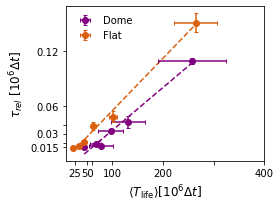

In [62]:
fig,ax = plt.subplots(figsize = (4,3))
BPsV = [0.04,0.03,0.02,0.01,0.007,0.003]
#for f in range(len(MP)):
#make a linear fit to the data
x,y = np.array(TurnoverOG),np.array(Avtaus)
# linear fir of y with y=mc+c
m, b = np.polyfit(x, y, 1)
x2,y2 = np.array(TurnoverDome),np.array(Dometaus)
m2, b2 = np.polyfit(x2, y2, 1)
#12 = x.transpose()
#Make a transpose of the x data
x12 = x.reshape(-1,1)
a, _, _, _ = np.linalg.lstsq(x12, y)
x22 = x2.reshape(-1,1)
a2, _, _, _ = np.linalg.lstsq(x22, y2)
ax.plot(x, np.divide(np.add(np.multiply(m,x), b),10**6),linestyle = '--',color = "#d95f0e")
#ax.plot(x, np.divide(np.add(np.multiply(a,x12), 0),10**6),linestyle = '--',color = "#d95f0e")
#ax.plot(x2, np.divide(np.add(np.multiply(a2,x2), 0),10**6),linestyle = '--',color = "purple")
ax.plot(x2, np.divide(np.add(np.multiply(m2,x2), b2),10**6),linestyle = '--',color ='purple')
ax.errorbar(TurnoverDome[:],np.divide(Dometaus[:],10**6), xerr = TurnoverErrorDome[:],yerr = np.divide(StdDometaus[:],10**6),capsize = 2,linestyle = '',color = 'purple',marker = 'o',markersize = 6,label = 'Dome') ##Would this by x2??
ax.errorbar(TurnoverOG[:],np.divide(Avtaus[:],10**6), xerr = TurnoverErrorOG[:],yerr = np.divide(Stdtaus[:],10**6),capsize = 2,linestyle = '',color = "#d95f0e",marker = 'o',markersize = 6,label = 'Flat') ##Would this by x2??
#ax.plot([35,250],[0.015,0.08],linestyle = '--',color = 'black') #ClrsOrange[3])
#ax.plot([40,300],[0.0005*25,0.0005*230],linestyle = '--',color = 'purple')## add original 
#ax.plot([17,300],[0.0005*20,0.0005*300],linestyle = '--',color = "#d95f0e")

print('Slope OG:',m, 'intercept:',b/10**6)
print('Slope Dome:',m2, 'intercept:',b2/10**6)
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$\tau_{rel}$ [$10^6\Delta t$]",fontsize = 12)
ax.legend(frameon=False)
ax.set_xticks([25,50,60,100,200,300,400],['25','50','','100','200','','400'])
ax.set_yticks([0.015,0.02,0.03,0.04,0.06,0.12],['0.015','','0.03','','0.06','0.12'])
plotname = 'DomeMasterFig_wtOG_Normal.pdf'
fig.tight_layout()
fig.savefig(plotsdir+plotname)

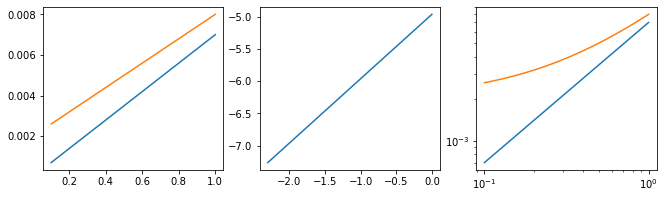

In [28]:
fig,ax=plt.subplots(1,3,figsize = (11,3))
x = np.linspace(0.1, 1, 100)
y=x*0.007
y2=x*0.006+0.002
#ax[0].plot([0.1,1],[6,34],linestyle = '--',color = 'purple')
#ax[1].plot([0.1,1],[6,36],linestyle = '--',color = 'purple')
#ax[2].plot([0.1,1],[6,34],linestyle = '--',color = 'purple')
ax[0].plot(x,y)
ax[0].plot(x,y2)
ax[1].plot(np.log(x),np.log(y))
ax[2].plot(x,y)
ax[2].plot(x,y2)
ax[2].set_yscale('log')
ax[2].set_xscale('log')
